In [4]:
#DATA CLEANING
# Objective: Prepare raw Online Retail data for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
# Load the Excel file
df = pd.read_excel('../data/Online Retail.xlsx')

print(f"Original dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst few rows:")
df.head()


Original dataset shape: (541909, 8)

Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

First few rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:


print(f"\nBasic statistics:")
print(df.describe())
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nMissing value percentages:")
print((df.isnull().sum() / len(df) * 100).round(2))



Basic statistics:
            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.000000  
std      1713.600303  

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice       

In [6]:

#HANDLE MISSING VALUES

rows_before = len(df)
df = df.dropna(subset=['CustomerID'])
rows_after = len(df)

print(f"Removed {rows_before - rows_after} rows with missing CustomerID")
print(f"Remaining rows: {rows_after}")

df['CustomerID'] = df['CustomerID'].astype(int)



Removed 135080 rows with missing CustomerID
Remaining rows: 406829


In [7]:

# REMOVE CANCELLED ORDERS
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
cancelled_mask = df['InvoiceNo'].str.startswith('C')

print(f"Cancelled orders found: {cancelled_mask.sum()}")

df = df[~cancelled_mask]
print(f"Remaining rows: {len(df)}")


Cancelled orders found: 8905
Remaining rows: 397924


In [8]:

#FILTER INVALID VALUES

print(f"Negative quantities: {(df['Quantity'] < 0).sum()}")
print(f"Zero quantities: {(df['Quantity'] == 0).sum()}")
print(f"Negative prices: {(df['UnitPrice'] < 0).sum()}")
print(f"Zero prices: {(df['UnitPrice'] == 0).sum()}")

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"Remaining rows: {len(df)}")


Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 40
Remaining rows: 397884


In [9]:

# TOTAL AMOUNT

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
print(df['TotalAmount'].describe())

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64


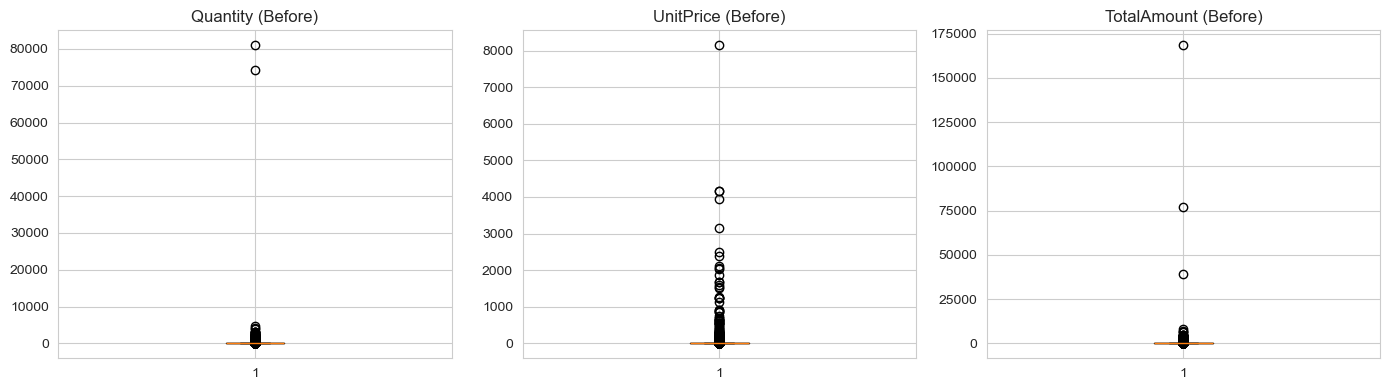

Quantity: Removed 25647 outliers (Range: [-13.00, 27.00])
UnitPrice: Removed 34086 outliers (Range: [-2.50, 7.50])
TotalAmount: Removed 13435 outliers (Range: [-16.60, 37.80])

Final row count: 324716


In [10]:

# HANDLE OUTLIERS


def remove_outliers_iqr(data, column, multiplier=1.5):
    """Remove outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    
    before = len(data)
    filtered = data[(data[column] >= lower) & (data[column] <= upper)]
    after = len(filtered)
    
    print(f"{column}: Removed {before - after} outliers (Range: [{lower:.2f}, {upper:.2f}])")
    return filtered

# Visualize before outlier removal
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].boxplot(df['Quantity'])
axes[0].set_title('Quantity (Before)')
axes[1].boxplot(df['UnitPrice'])
axes[1].set_title('UnitPrice (Before)')
axes[2].boxplot(df['TotalAmount'])
axes[2].set_title('TotalAmount (Before)')
plt.tight_layout()
plt.savefig('../outputs/figures/outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()

# Remove outliers
df = remove_outliers_iqr(df, 'Quantity')
df = remove_outliers_iqr(df, 'UnitPrice')
df = remove_outliers_iqr(df, 'TotalAmount')

print(f"\nFinal row count: {len(df)}")


In [11]:

#FINAL DATA CHECK

print(f"Final dataset shape: {df.shape}")
print(f"\nUnique values:")
print(f"  Customers: {df['CustomerID'].nunique()}")
print(f"  Products: {df['StockCode'].nunique()}")
print(f"  Invoices: {df['InvoiceNo'].nunique()}")
print(f"  Countries: {df['Country'].nunique()}")
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")


Final dataset shape: (324716, 9)

Unique values:
  Customers: 4146
  Products: 3319
  Invoices: 16245
  Countries: 37

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [12]:

#SAVE CLEANED DATA
df.to_csv('../data/online_retail_cleaned.csv', index=False)
print("Cleaned data saved to '../data/online_retail_cleaned.csv'")

Cleaned data saved to '../data/online_retail_cleaned.csv'
